In [162]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [184]:
#PUTTING FILEPATHS FOR INPUT AND OUTPUT
import os

DATA_DIR = "/content/drive/MyDrive/fmri_project/fmriprep_Alzheimers_data"
OUTPUT_DIR = "/content/drive/MyDrive/fmri_project/outputs"

print(os.listdir(DATA_DIR))

['sub-012S6760_task-rest_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 'sub-016S6790_task-rest_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 'sub-016S6839_task-rest_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 'sub-126S4507_task-rest_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 'sub-137S4862_task-rest_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 'sub-168S6541_task-rest_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 'sub-168S6821_task-rest_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 'sub-012S6760_task-rest_desc-confounds_timeseries.tsv', 'sub-016S6790_task-rest_desc-confounds_timeseries.tsv', 'sub-016S6839_task-rest_desc-confounds_timeseries.tsv', 'sub-126S4507_task-rest_desc-confounds_timeseries.tsv', 'sub-168S6541_task-rest_desc-confounds_timeseries.tsv', 'sub-137S4862_task-rest_desc-confounds_timeseries.tsv', 'sub-168S6821_task-rest_desc-confounds_timeseries.tsv', 'sub-127S6433_task-rest_desc-confounds_timeseries.tsv', 'sub-127S643

In [24]:
!pip install nilearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 53.4 MB/s eta 0:00:00


In [164]:
#GETTING REPITION TIME VALUES (IMPORTANT FOR NILEARN PREPROCESSING)
import pandas as pd

csv1 = pd.read_csv("/content/drive/MyDrive/fmri_project/fmriprep_Control_data/subject_trs_aadi.csv")
csv2 = pd.read_csv("/content/drive/MyDrive/fmri_project/fmriprep_Control_data/subject_trs_rushil.csv")
csv3 = pd.read_csv("/content/drive/MyDrive/fmri_project/fmriprep_Control_data/subject_trs_AD_aadi.csv")
csv4 = pd.read_csv("/content/drive/MyDrive/fmri_project/fmriprep_Control_data/subject_trs_AD_aadi 2.csv")

tr_df = pd.concat([csv1, csv2, csv3,csv4])
tr_df = tr_df.drop_duplicates(
    subset='subject'
)

tr_df.to_csv(
    "/content/drive/MyDrive/merged_tr_values.csv",
    index=False
)

print(tr_df.head())
print(tr_df.shape)

tr_lookup = dict(zip(tr_df['subject'], tr_df['TR']))

        subject     TR
0  sub-127S0259  3.000
1  sub-016S4951  3.000
2  sub-941S7046  0.607
3  sub-094S4649  3.000
4  sub-073S4552  0.607
(83, 2)


In [165]:
#GETTING AGE AND MMSE SCORES (AVAILABLE ONLY THROUGH ADNI WEBSITE SO HAVE TO READ A DIFFERENT SHEET)

details_df = pd.read_excel("/content/drive/MyDrive/fmri_project/Patients_metadata/Control Patients List.xlsx", sheet_name="Sheet1", header=1)
details_df = details_df.loc[:, ~details_df.columns.str.contains('^Unnamed')]

details_df['subject'] = (
    "sub-" +
    details_df['Patient ID']
    .astype(str)
    .str.replace("_", "", regex=False)
)

details_df = details_df[['subject', 'Age', 'MMSE']]

age_lookup = dict(
    zip(details_df['subject'], details_df['Age'])
)

mmse_lookup = dict(
    zip(details_df['subject'], details_df['MMSE'])
)

In [185]:
#GETTING COUNT OF NUMBER OF SCANS
import glob

bold_files = glob.glob(DATA_DIR + "/*.nii.gz")
confound_files = glob.glob(DATA_DIR + "/*.tsv")

print("BOLD:", len(bold_files))
print("Confounds:", len(confound_files))

BOLD: 17
Confounds: 17


In [186]:
#EXTRACTING THE PREPROCESSED FMRI SCANS FROM FMRIPREP
bold_files = sorted(glob.glob(DATA_DIR + "/*desc-preproc_bold.nii.gz"))

from nilearn import image
imgs = [image.load_img(f) for f in bold_files]

subjects = [
    os.path.basename(f).split("_")[0]
    for f in bold_files
]


In [187]:
#CONFOUND TIMESERIES DATA CODE
confound_files = []

for f in bold_files:
    base = f.split("/")[-1]  # get filename
    base = base.split("_space")[0]  # remove space part

    confound_path = DATA_DIR + "/" + base + "_desc-confounds_timeseries.tsv"
    confound_files.append(confound_path)
import pandas as pd

def load_confounds(path):
    confounds = pd.read_csv(path, sep="\t")

    cols = [
    'trans_x', 'trans_y', 'trans_z',
    'rot_x', 'rot_y', 'rot_z',

    'trans_x_derivative1',
    'trans_y_derivative1',
    'trans_z_derivative1',
    'rot_x_derivative1',
    'rot_y_derivative1',
    'rot_z_derivative1',

    'white_matter',
    'csf',

    'global_signal',

    'framewise_displacement',

    'a_comp_cor_00',
    'a_comp_cor_01',
    'a_comp_cor_02',
    'a_comp_cor_03',
    'a_comp_cor_04'
]

    cols = [c for c in cols if c in confounds.columns]

    return confounds[cols].fillna(0).values


confounds_list = [load_confounds(f) for f in confound_files]

In [188]:
#ATLAS IMAGE CODE
import nibabel as nib

atlas_img = nib.load(
    "/content/drive/MyDrive/fmri_project/Atlas/ROI_MNI_V5.nii"
)

labels = []

with open("/content/drive/MyDrive/fmri_project/Atlas/ROI_MNI_V5.txt") as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) > 1:
            labels.append(parts[1])

#print(labels)
print(len(labels))


#GETTING THE LABELS

left_idx = [
    i for i, lbl in enumerate(labels)
    if lbl.endswith("_L")
]

right_idx = [
    i for i, lbl in enumerate(labels)
    if lbl.endswith("_R")
]

excluded = [
    lbl for lbl in labels
    if "_L" not in lbl and "_R" not in lbl
]


print(len(left_idx), "Left regions taken")
print(len(right_idx), "Right Regions taken")
print("THESE REGIONS ARE NOT INCLUDED", excluded)

120
56 Left regions taken
56 Right Regions taken
THESE REGIONS ARE NOT INCLUDED ['Vermis_1_2', 'Vermis_3', 'Vermis_4_5', 'Vermis_6', 'Vermis_7', 'Vermis_8', 'Vermis_9', 'Vermis_10']


In [189]:
#NILEARN PREPROCESSING STEP
#MAKES

from nilearn.input_data import NiftiLabelsMasker
from nilearn.image import resample_to_img

time_series_list = []

ages = []
mmse_scores = []
valid_subjects = []

for subj, img, conf in zip(subjects, imgs, confounds_list):

    atlas_resampled = resample_to_img(
        atlas_img,
        img,
        interpolation='nearest'
    )

    if subj not in tr_lookup:
        continue
    if subj not in age_lookup:
        continue

    tr = tr_lookup[subj]

    masker = NiftiLabelsMasker(
        labels_img=atlas_resampled,
        standardize=True,
        detrend=True,
        low_pass=0.1,
        high_pass=0.01,
        t_r=tr
    )

    ts = masker.fit_transform(img, confounds=conf)
    time_series_list.append(ts)
    ages.append(age_lookup[subj])
    mmse_scores.append(mmse_lookup[subj])
    valid_subjects.append(subj)


print(len(time_series_list))
print(time_series_list[0].shape)

/tmp/ipykernel_28599/2397312888.py:37: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  ts = masker.fit_transform(img, confounds=conf)
/tmp/ipykernel_28599/2397312888.py:37: DeprecationWarning: From release 0.14.0, confounds will be standardized using the sample std instead of the population std.
  ts = masker.fit_transform(img, confounds=conf)
/tmp/ipykernel_28599/2397312888.py:37: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid thi

15
(197, 120)


/tmp/ipykernel_28599/2397312888.py:37: DeprecationWarning: From release 0.14.0, confounds will be standardized using the sample std instead of the population std.
  ts = masker.fit_transform(img, confounds=conf)


In [190]:
import numpy as np

connectivity_matrices = []

for ts in time_series_list:
    corr = np.corrcoef(ts.T)
    connectivity_matrices.append(corr)

#EXTRACT FC MATRICES FOR LL, RR, AND LR
X = np.array(connectivity_matrices)
print(X.shape)

LL = X[:, left_idx][:, :, left_idx]
RR = X[:, right_idx][:, :, right_idx]
LR = X[:, left_idx][:, :, right_idx]

(15, 120, 120)


In [191]:
# FLATTEN FEATURES
triu_FULL = np.triu_indices(X.shape[1],k=1)
triu_LL = np.triu_indices(len(left_idx), k=1)
triu_RR = np.triu_indices(len(right_idx), k=1)

FULL_features = np.array([
    mat[triu_FULL]
    for mat in X
])

LL_features = np.array([
    mat[triu_LL]
    for mat in LL
])

RR_features = np.array([
    mat[triu_RR]
    for mat in RR
])

LR_features = LR.reshape(
    LR.shape[0],
    -1
)

print(FULL_features.shape)
print(LL_features.shape)
print(RR_features.shape)
print(LR_features.shape)

(15, 7140)
(15, 1540)
(15, 1540)
(15, 3136)


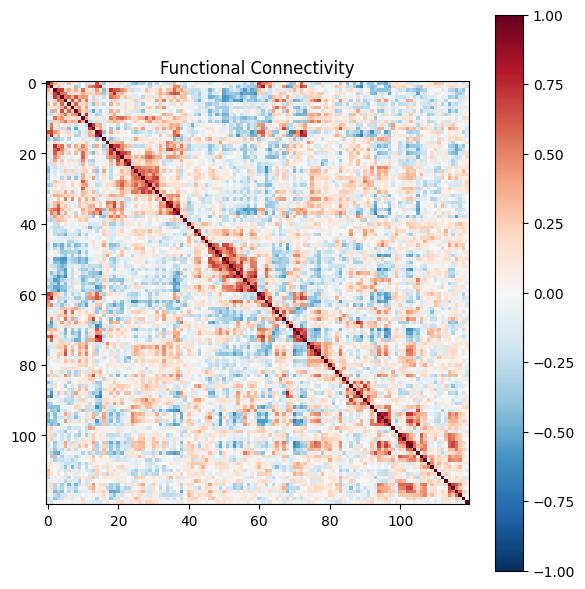

In [196]:
test = 4

import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))
plt.imshow(connectivity_matrices[test], cmap='RdBu_r', vmin=-1, vmax=1)
plt.title("Functional Connectivity")
plt.colorbar()
plt.tight_layout()
plt.show()

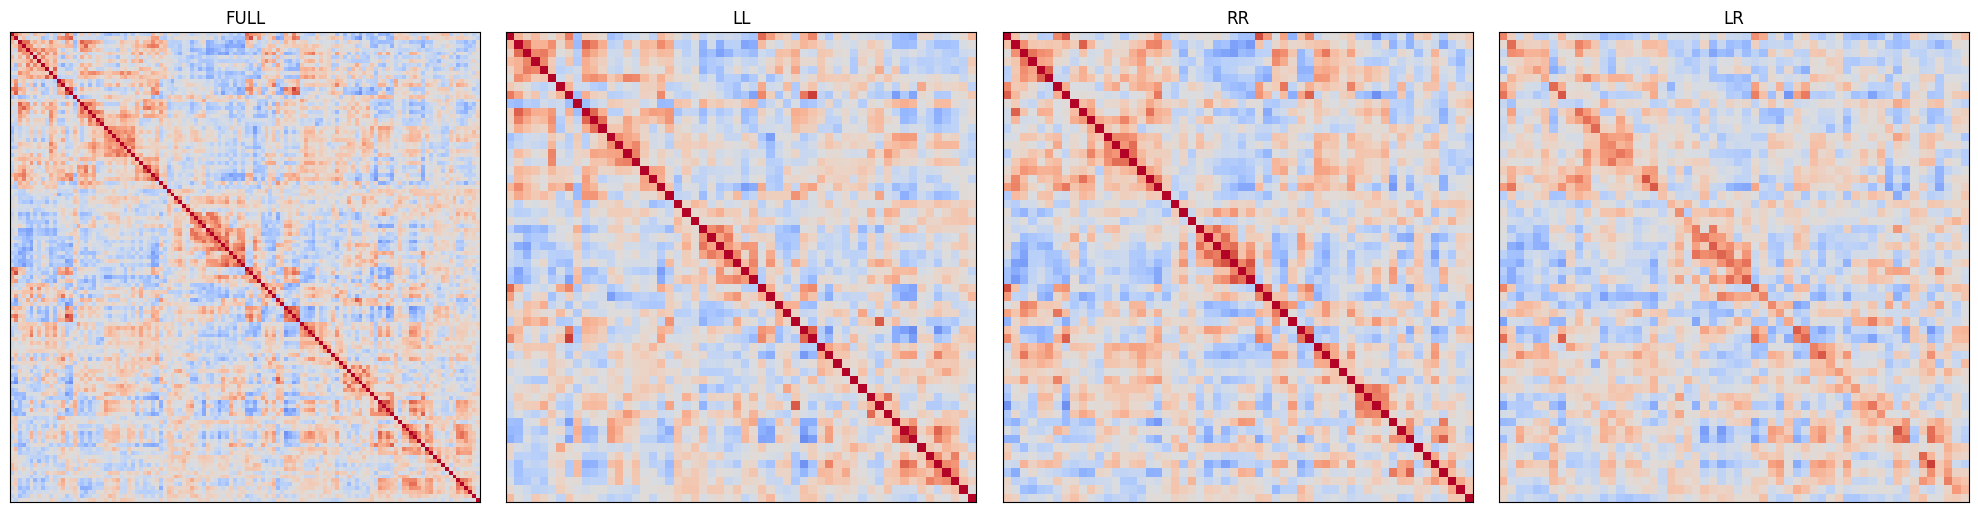

In [197]:
import matplotlib.pyplot as plt
import numpy as np

# choose subject index
i = 4

full_mat = X[i]
ll_mat = LL[i]
rr_mat = RR[i]
lr_mat = LR[i]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(full_mat, cmap='coolwarm', vmin=-1, vmax=1)
axes[0].set_title("FULL")

axes[1].imshow(ll_mat, cmap='coolwarm', vmin=-1, vmax=1)
axes[1].set_title("LL")

axes[2].imshow(rr_mat, cmap='coolwarm', vmin=-1, vmax=1)
axes[2].set_title("RR")

axes[3].imshow(lr_mat, cmap='coolwarm', vmin=-1, vmax=1)
axes[3].set_title("LR")

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

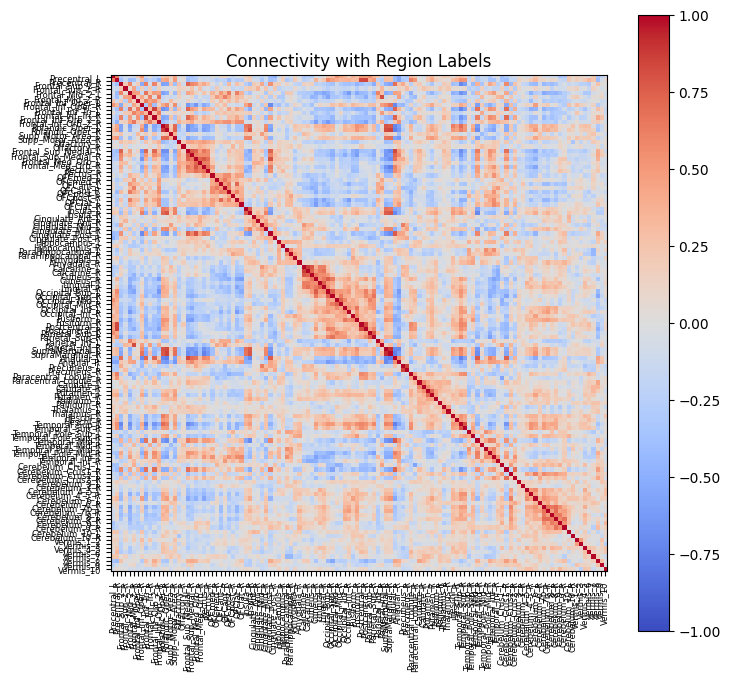

In [183]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.imshow(connectivity_matrices[7], cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()

plt.xticks(range(len(labels)), labels, rotation=90, fontsize=6)
plt.yticks(range(len(labels)), labels, fontsize=6)

plt.title("Connectivity with Region Labels")
plt.show()

In [69]:
threshold = 0.5
mat = cn_matrices[20]   # pick subject (change index if needed)

for i in range(len(labels)):
    for j in range(i+1, len(labels)):  # avoids i=j and duplicates
        if mat[i, j] > threshold:
            print(f"{labels[i]} <-> {labels[j]} : {mat[i, j]:.2f}")

Precentral_L <-> Precentral_R : 0.54
Precentral_L <-> Frontal_Mid_2_L : 0.52
Precentral_L <-> Frontal_Inf_Oper_L : 0.53
Precentral_L <-> Frontal_Inf_Tri_L : 0.56
Precentral_L <-> Supp_Motor_Area_L : 0.60
Precentral_L <-> Parietal_Sup_L : 0.52
Precentral_L <-> Parietal_Inf_L : 0.67
Precentral_R <-> Rolandic_Oper_R : 0.50
Precentral_R <-> Supp_Motor_Area_R : 0.67
Precentral_R <-> Postcentral_L : 0.77
Precentral_R <-> Postcentral_R : 0.68
Frontal_Sup_2_L <-> Frontal_Mid_2_L : 0.65
Frontal_Sup_2_L <-> Frontal_Sup_Medial_L : 0.69
Frontal_Sup_2_L <-> Frontal_Med_Orb_L : 0.69
Frontal_Sup_2_L <-> OFCpost_L : 0.55
Frontal_Sup_2_L <-> Cingulate_Post_L : 0.67
Frontal_Sup_2_L <-> Angular_L : 0.81
Frontal_Sup_2_L <-> Precuneus_L : 0.72
Frontal_Sup_2_L <-> Temporal_Mid_L : 0.51
Frontal_Sup_2_L <-> Temporal_Pole_Mid_R : 0.60
Frontal_Sup_2_L <-> Cerebelum_Crus1_R : 0.66
Frontal_Sup_2_L <-> Cerebelum_Crus2_R : 0.62
Frontal_Sup_2_L <-> Cerebelum_7b_R : 0.57
Frontal_Sup_2_R <-> Frontal_Sup_Medial_R : 0.6

In [179]:
#FINAL CHECK
for i in range(5):

    print(
        valid_subjects[i],
        ages[i],
        mmse_scores[i],
        connectivity_matrices[i].shape
    )

sub-002S1261 71.1 30 (120, 120)
sub-002S1280 70.7 30 (120, 120)
sub-003S4441 68.7 30 (120, 120)
sub-003S4872 68.5 26 (120, 120)
sub-003S6014 67.1 30 (120, 120)


In [198]:
np.savez(
    OUTPUT_DIR + "/fmri_features_AD.npz",

    FULL=FULL_features,
    LL=LL_features,
    RR=RR_features,
    LR=LR_features,

    ages=np.array(ages),
    mmse=np.array(mmse_scores),
    subjects=np.array(valid_subjects)
)